In [15]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator

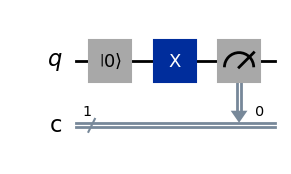

In [16]:
qc = QuantumCircuit(1,1) #Number of qubits and number of classical bits to store info
qc.reset(0)
qc.x(0)
qc.measure(0,0) #Measured a qubit zero and store it in zero
qc.draw('mpl')

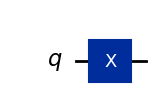

In [17]:
qc_x = QuantumCircuit(1)
qc_x.x(0)
qc_x.draw('mpl')

In [20]:
X = Operator(qc_x)
X.draw('latex')

<IPython.core.display.Latex object>

In [25]:
ket_0 = Statevector.from_label('0')
ket_0.draw('latex')

<IPython.core.display.Latex object>

In [27]:
ket_0.evolve(X).draw('latex')

<IPython.core.display.Latex object>

In [28]:
ket_1 = Statevector.from_label('1')
ket_1.draw('latex')

<IPython.core.display.Latex object>

In [30]:
ket_1.evolve(X).draw('latex')

<IPython.core.display.Latex object>

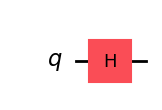

In [32]:
qc_h = QuantumCircuit(1) #It has got one qubit
qc_h.h(0)
qc_h.draw('mpl')

In [34]:
H = Operator(qc_h)
H.draw('latex')

<IPython.core.display.Latex object>

In [35]:
ket_p = ket_0.evolve(H)
ket_p.draw('latex')

<IPython.core.display.Latex object>

In [36]:
ket_m = ket_1.evolve(H)
ket_m.draw('latex')

<IPython.core.display.Latex object>

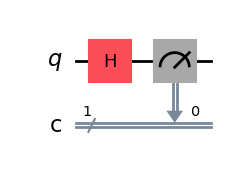

In [37]:
qc = QuantumCircuit(1,1) #Number of qubits and number of classical bits to store info
qc.h(0)
qc.measure(0,0) #Measured a qubit zero and store it in zero
qc.draw('mpl')

In [39]:
from qiskit.providers.basic_provider import BasicSimulator

simulator = BasicSimulator()
job = simulator.run(qc, shots = 100)
result = job.result()
counts = result.get_counts()
print(counts)

{'0': 56, '1': 44}


Statevector:


<IPython.core.display.Latex object>

Circuit:


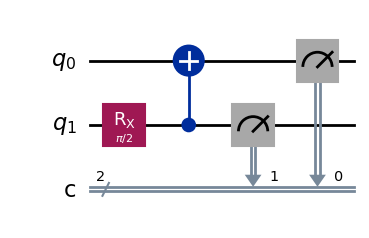

Probability Distribution:


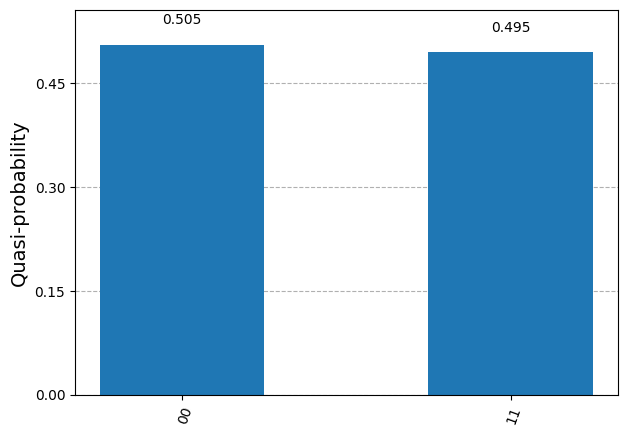

In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_distribution
from qiskit_aer import AerSimulator

simulator = AerSimulator()

qc = QuantumCircuit(2,2)
qc.rx(np.pi/2,1)
qc.cx(1,0)
print("Statevector:")
display(Statevector(qc).draw('latex'))

qc.measure([1,0],[1,0])

print("Circuit:")
display(qc.draw('mpl'))

qc_t = transpile(qc, simulator)
counts = simulator.run(qc, shots=2**10).result().get_counts()

print("Probability Distribution:")
plot_distribution(counts)